# Chirundu Town Council CDF Community Projects - 2024

## Purpose

This notebook extracts, cleans, validates and exports approved
CDF community project information published by Chirundu Town Council.

The source PDF is scanned, therefore OCR is used to extract the text
before the records are cleaned and structured.

## Final Dataset Fields

- project_name
- ward
- year
- approval_status
- project_type

In [1]:
import os
import pymupdf
import pytesseract
import pandas as pd
import cv2
import numpy as np

from PIL import Image
from IPython.display import display

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Program Files\Tesseract-OCR\tesseract.exe"
)

print("Libraries loaded successfully.")
print("Tesseract version:", pytesseract.get_tesseract_version())

Libraries loaded successfully.
Tesseract version: 5.4.0.20240606


## Source Document

The source document is the 2024 Chirundu Town Council approved CDF
community projects PDF.

The document contains a scanned table, so OCR is required to extract
the project information.

In [2]:
pdf_path = "raw/2024-CDF-approved-projects.pdf"

print("File exists:", os.path.exists(pdf_path))

File exists: True


In [3]:
doc = pymupdf.open(pdf_path)

print("PDF opened successfully.")
print("Number of pages:", len(doc))

PDF opened successfully.
Number of pages: 1


## Direct Text Extraction Test

Before OCR is applied, the notebook checks whether useful
machine-readable text can be extracted directly from the PDF.

Because the source is scanned, little or no useful text is expected.

In [4]:
for page_number, page in enumerate(doc):
    text = page.get_text().strip()

    print(
        f"Page {page_number + 1}:",
        len(text),
        "characters detected"
    )

Page 1: 0 characters detected


## OCR Extraction

The scanned PDF page is converted to a high-resolution image and
processed using Tesseract OCR.

The raw OCR output is later compared with the original PDF because OCR
may merge rows or incorrectly recognise some characters.

In [5]:
os.makedirs("notebooks/2024_ocr", exist_ok=True)

page = doc[0]

matrix = pymupdf.Matrix(3, 3)

pix = page.get_pixmap(
    matrix=matrix,
    alpha=False
)

image_path = "notebooks/2024_ocr/2024_cdf_page1.png"

pix.save(image_path)

print("Page image saved successfully:")
print(image_path)

Page image saved successfully:
notebooks/2024_ocr/2024_cdf_page1.png


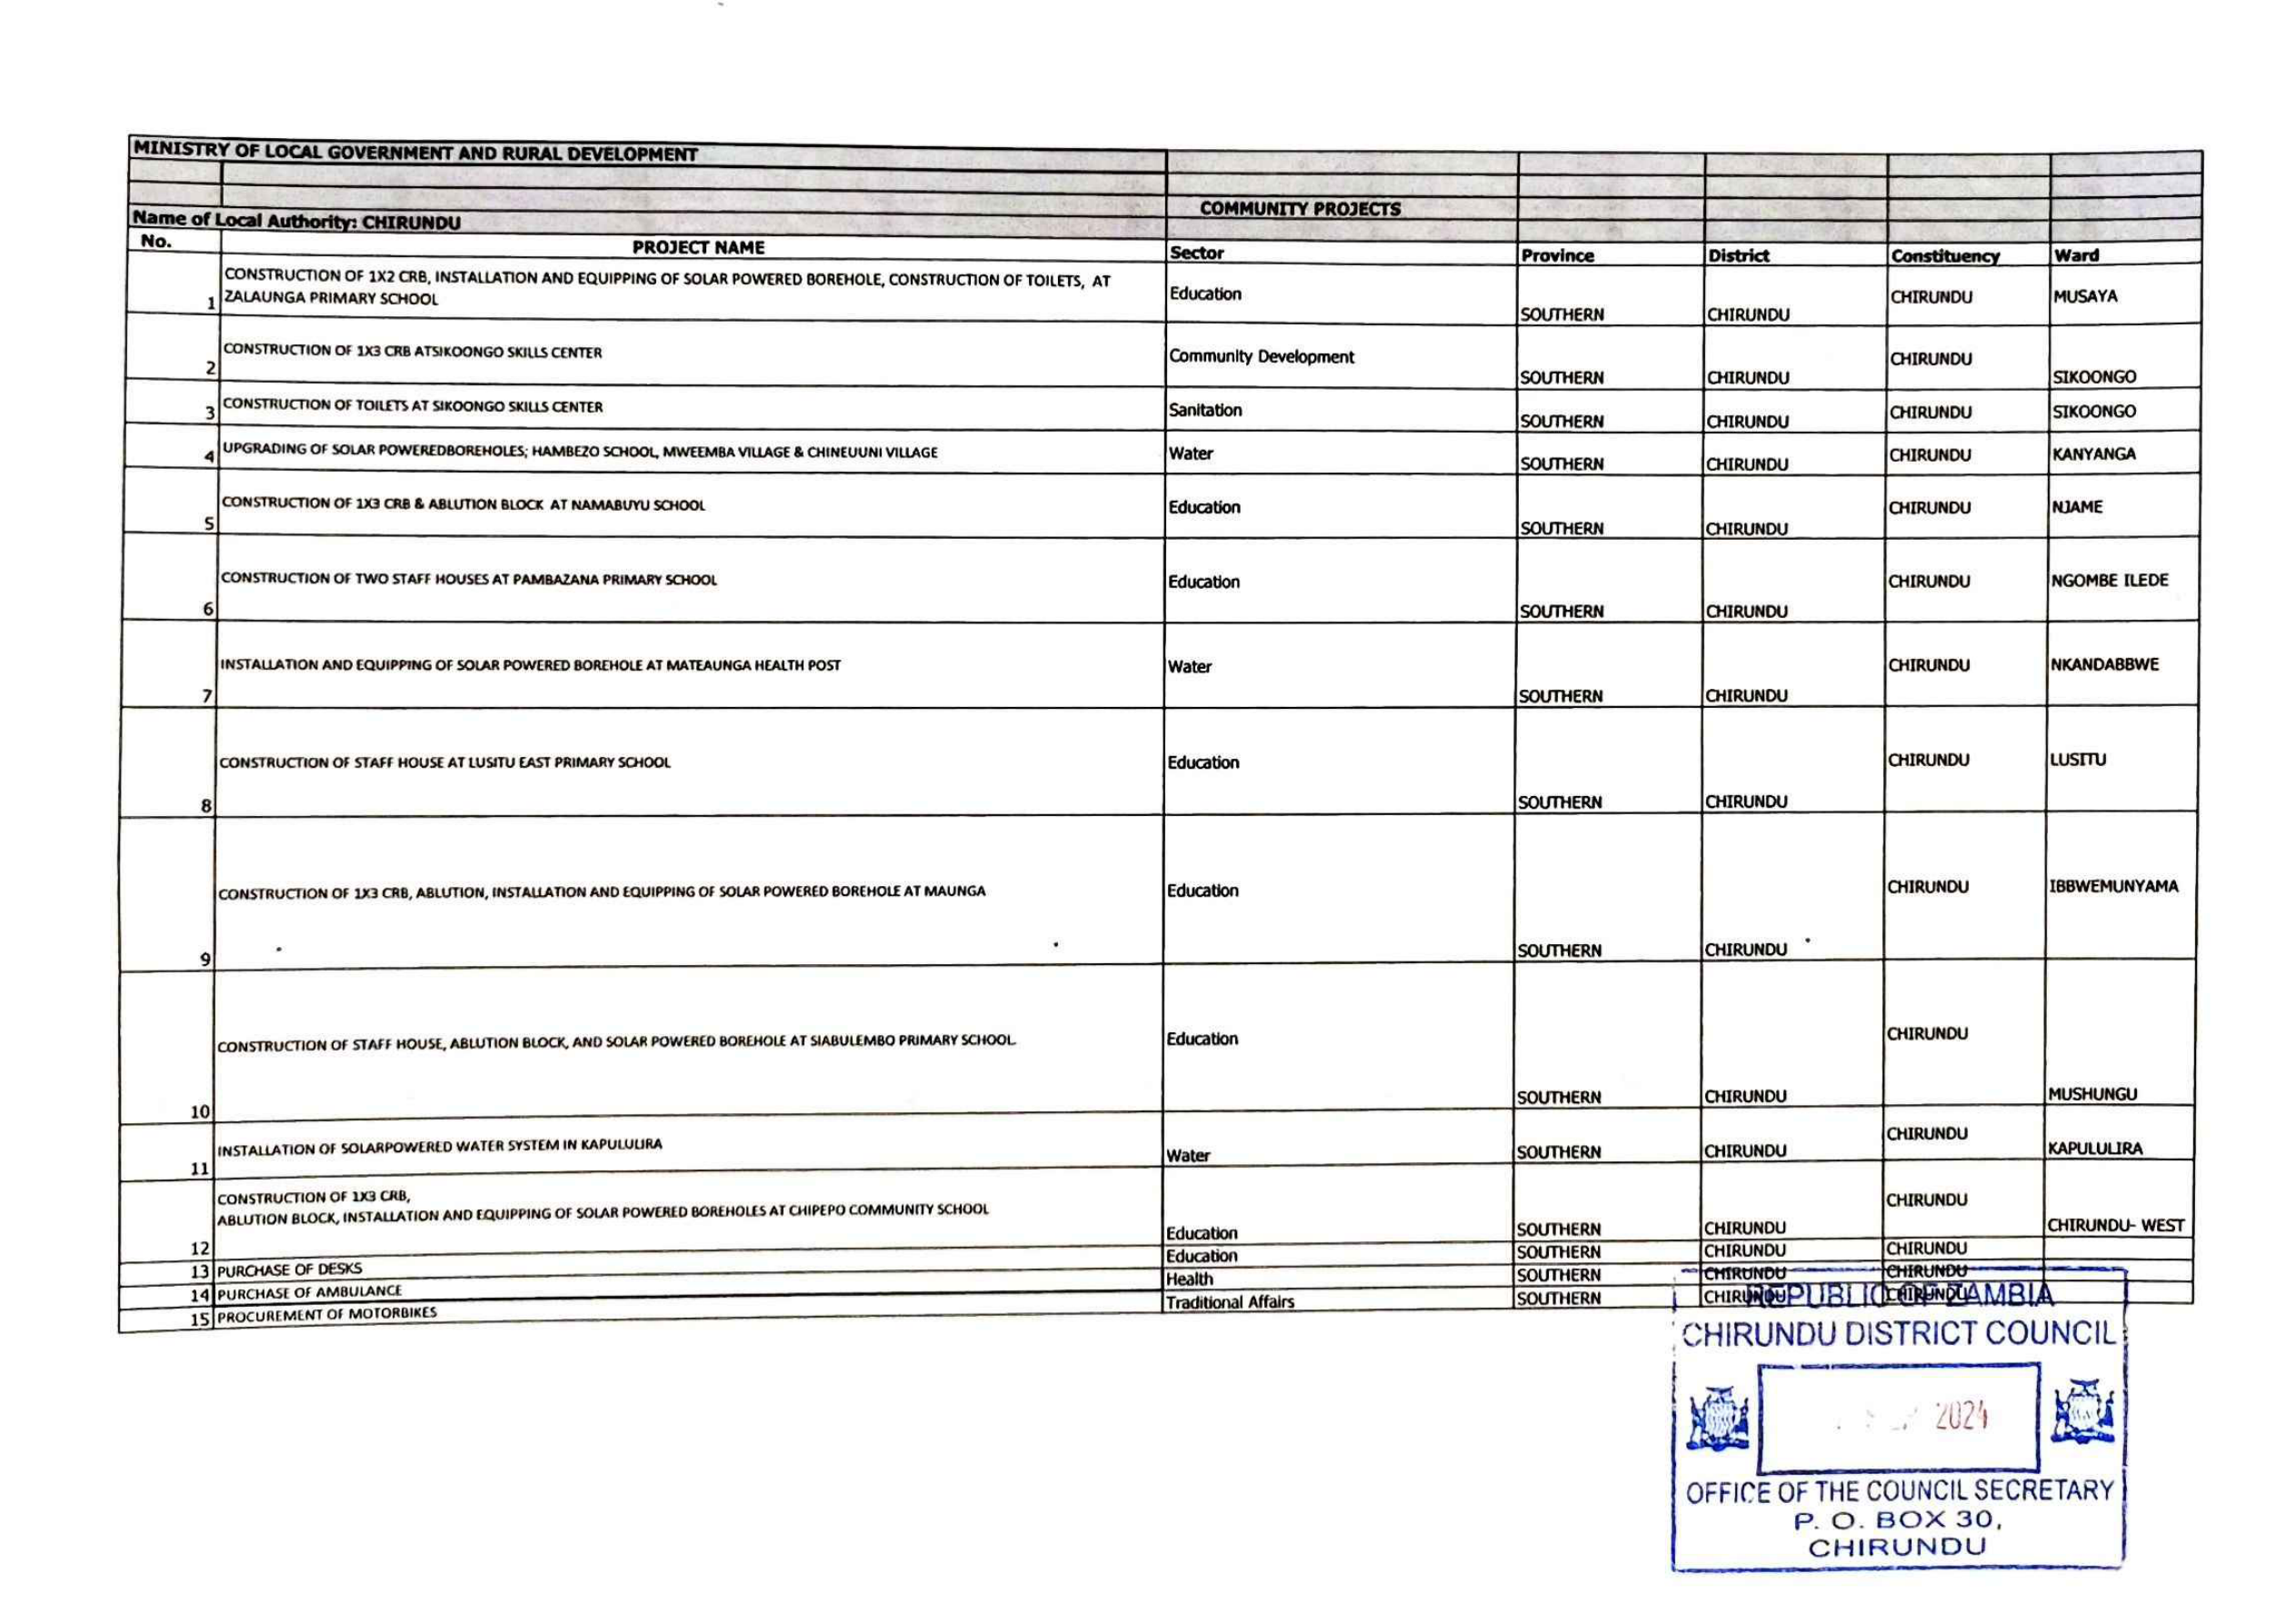

In [6]:
page_image = Image.open(image_path)

display(page_image)

In [7]:
image = cv2.imread(image_path)

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

ocr_text_2024 = pytesseract.image_to_string(
    gray,
    lang="eng",
    config="--psm 6"
)

print(ocr_text_2024)

MINISTRY OF LOCAL GOVERNMENT AND RURAL DEVELOPMENT | nn Sie ees Be oo tied Ta BO se Te
PSIG ROE SOLA SANTEE US eae RARITY RN DOORS SPR TRIS TD, ENR CE
ee I TNE ANAT SCS Te SR A PA a PN a.
CONSTRUCTION OF 1X2 CRB, INSTALLATION AND EQUIPPING OF SOLAR POWERED BOREHOLE, CONSTRUCTION OF TOILETS, AT
|ZALAUNGA PRIMARY SCHOOL Education IMUSAYA
J foomomencnamommmam siti “ue
CHIRUNDU SIKOONGO
a a
a a
few TWO STAFF HOUSES AT PAMBAZANA PRIMARY SCHOOL Education ee pm | NGOMBE ILEDE
CHIRUNDU
CONSTRUCTION OF STAFF HOUSE AT LUSITU EAST PRIMARY SCHOOL Education pas fom |
CHIRUNDU-
a eeeceemmieel oa Lk. —_
CONSTRUCTION Of STAFF HOUSE, ABLUTION BLOCK, AND SOLAR POWERED BOREHOLE AT SIABULEMBO PRIMARY SCHOOL Education fe | |
CHIRUNDU
pails Aen SOLAR POWERED BOREHOLES AT CHIPEPO COMMUNITY SCHOOL mms | eal
7 ‘TION AND EQUIPPING OF
JABLUTION BLOCK, INSTALLAT fz tion —_
fEucaton____|SOUTHERN__[CHIRUN a
| case Traditional Affars_ISouTHern | _Icwir SUPT [CeeepnpOA MBIA
|-——jsfenocuntentor woronowes
“CHIRUNDU DIS

In [8]:
ocr_output_path = (
    "notebooks/2024_ocr/"
    "2024_ocr_page1.txt"
)

with open(
    ocr_output_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(ocr_text_2024)

print("Raw OCR text saved successfully:")
print(ocr_output_path)

Raw OCR text saved successfully:
notebooks/2024_ocr/2024_ocr_page1.txt


## Data Cleaning and Curation

The OCR output was compared with the original 2024 PDF table.

Merged rows, incorrect OCR characters and spelling errors introduced
during OCR were corrected using the source document.

The following fields were used:

- `project_name`: extracted from the Project Name field.
- `ward`: extracted from the Ward field.
- `year`: assigned as 2024 from the source document year.
- `approval_status`: assigned as `Approved` because the source contains
  approved CDF projects.
- `project_type`: mapped from the Sector field in the source document.

In [9]:
projects_2024 = [
    {
        "project_name": "Construction of 1x2 CRB, Installation and Equipping of Solar Powered Borehole, Construction of Toilets, at Zalaunga Primary School",
        "ward": "Musaya",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of 1x3 CRB at Sikongo Skills Center",
        "ward": "Sikoongo",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Community Development"
    },
    {
        "project_name": "Construction of Toilets at Sikongo Skills Center",
        "ward": "Sikoongo",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Sanitation"
    },
    {
        "project_name": "Upgrading of Solar Powered Boreholes; Hambezo School, Mweemba Village & Chienjuni Village",
        "ward": "Kanyanga",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Water"
    },
    {
        "project_name": "Construction of 1x3 CRB & Ablution Block at Namabuyu School",
        "ward": "Njame",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of Two Staff Houses at Pambazana Primary School",
        "ward": "Ngombe Ilede",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Installation and Equipping of Solar Powered Borehole at Matealinga Health Post",
        "ward": "Nkandabbwe",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Water"
    },
    {
        "project_name": "Construction of Staff House at Lusitu East Primary School",
        "ward": "Lusitu",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of 1x3 CRB, Ablution, Installation and Equipping of Solar Powered Borehole at Maunga",
        "ward": "Ibbwemunyama",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of Staff House, Ablution Block, and Solar Powered Borehole at Siabulembo Primary School",
        "ward": "Mushungu",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Installation of Solar Powered Water System in Kapululira",
        "ward": "Kapululira",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Water"
    },
    {
        "project_name": "Construction of 1x3 CRB, Ablution Block, Installation and Equipping of Solar Powered Boreholes at Chipepo Community School",
        "ward": "Chirundu West",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Purchase of Desks",
        "ward": "All 12 Wards",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Purchase of Ambulance",
        "ward": "All 12 Wards",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Health"
    },
    {
        "project_name": "Procurement of Motorbikes",
        "ward": "All 12 Wards",
        "year": 2024,
        "approval_status": "Approved",
        "project_type": "Traditional Affairs"
    }
]

df_2024 = pd.DataFrame(projects_2024)

display(df_2024)

,project_name,ward,year,approval_status,project_type
0,"Construction of 1x2 CRB, Installation and Equi...",Musaya,2024,Approved,Education
1,Construction of 1x3 CRB at Sikongo Skills Center,Sikoongo,2024,Approved,Community Development
2,Construction of Toilets at Sikongo Skills Center,Sikoongo,2024,Approved,Sanitation
3,Upgrading of Solar Powered Boreholes; Hambezo ...,Kanyanga,2024,Approved,Water
4,Construction of 1x3 CRB & Ablution Block at Na...,Njame,2024,Approved,Education
5,Construction of Two Staff Houses at Pambazana ...,Ngombe Ilede,2024,Approved,Education
6,Installation and Equipping of Solar Powered Bo...,Nkandabbwe,2024,Approved,Water
7,Construction of Staff House at Lusitu East Pri...,Lusitu,2024,Approved,Education
8,"Construction of 1x3 CRB, Ablution, Installatio...",Ibbwemunyama,2024,Approved,Education
9,"Construction of Staff House, Ablution Block, a...",Mushungu,2024,Approved,Education


## Data Validation

The cleaned dataset is checked for:

- expected number of records
- correct column structure
- missing values
- duplicate records
- year consistency
- approval status consistency
- project types
- ward values

In [10]:
print("Dataset shape:", df_2024.shape)

print("\nColumns:")
print(df_2024.columns.tolist())

print("\nMissing values:")
print(df_2024.isnull().sum())

print("\nDuplicate rows:")
print(df_2024.duplicated().sum())

print("\nYear values:")
print(df_2024["year"].value_counts())

print("\nApproval status:")
print(df_2024["approval_status"].value_counts())

print("\nProject types:")
print(df_2024["project_type"].value_counts())

print("\nWards:")
print(df_2024["ward"].value_counts())

Dataset shape: (15, 5)

Columns:
['project_name', 'ward', 'year', 'approval_status', 'project_type']

Missing values:
project_name       0
ward               0
year               0
approval_status    0
project_type       0
dtype: int64

Duplicate rows:
0

Year values:
year
2024    15
Name: count, dtype: int64

Approval status:
approval_status
Approved    15
Name: count, dtype: int64

Project types:
project_type
Education                8
Water                    3
Community Development    1
Sanitation               1
Health                   1
Traditional Affairs      1
Name: count, dtype: int64

Wards:
ward
All 12 Wards     3
Sikoongo         2
Musaya           1
Kanyanga         1
Njame            1
Ngombe Ilede     1
Nkandabbwe       1
Lusitu           1
Ibbwemunyama     1
Mushungu         1
Kapululira       1
Chirundu West    1
Name: count, dtype: int64


In [11]:
expected_columns = [
    "project_name",
    "ward",
    "year",
    "approval_status",
    "project_type"
]

if list(df_2024.columns) == expected_columns:
    print("Column structure is correct.")
else:
    print("Column structure needs correction.")

Column structure is correct.


## Export Final Dataset

The cleaned dataset is exported in CSV format using the pipe character
`|` as the column separator.

The filename follows the dataset naming convention required by the
assignment.

In [12]:
os.makedirs("processed", exist_ok=True)

output_path = (
    "processed/"
    "db-unza26-csc4792-chirundu_cdf_projects_2024.csv"
)

df_2024.to_csv(
    output_path,
    sep="|",
    index=False,
    encoding="utf-8"
)

print("Dataset exported successfully:")
print(output_path)

Dataset exported successfully:
processed/db-unza26-csc4792-chirundu_cdf_projects_2024.csv


In [13]:
final_check = pd.read_csv(
    output_path,
    sep="|"
)

print("Rows:", len(final_check))
print("Columns:", len(final_check.columns))

display(final_check)

Rows: 15
Columns: 5


,project_name,ward,year,approval_status,project_type
0,"Construction of 1x2 CRB, Installation and Equi...",Musaya,2024,Approved,Education
1,Construction of 1x3 CRB at Sikongo Skills Center,Sikoongo,2024,Approved,Community Development
2,Construction of Toilets at Sikongo Skills Center,Sikoongo,2024,Approved,Sanitation
3,Upgrading of Solar Powered Boreholes; Hambezo ...,Kanyanga,2024,Approved,Water
4,Construction of 1x3 CRB & Ablution Block at Na...,Njame,2024,Approved,Education
5,Construction of Two Staff Houses at Pambazana ...,Ngombe Ilede,2024,Approved,Education
6,Installation and Equipping of Solar Powered Bo...,Nkandabbwe,2024,Approved,Water
7,Construction of Staff House at Lusitu East Pri...,Lusitu,2024,Approved,Education
8,"Construction of 1x3 CRB, Ablution, Installatio...",Ibbwemunyama,2024,Approved,Education
9,"Construction of Staff House, Ablution Block, a...",Mushungu,2024,Approved,Education


In [14]:
print("Final verification")

print(
    "Same number of rows:",
    len(final_check) == len(df_2024)
)

print(
    "Same columns:",
    list(final_check.columns) == list(df_2024.columns)
)

print(
    "Missing values:",
    final_check.isnull().sum().sum()
)

print(
    "Duplicates:",
    final_check.duplicated().sum()
)

Final verification
Same number of rows: True
Same columns: True
Missing values: 0
Duplicates: 0


## Conclusion

The 2024 Chirundu Town Council approved CDF community projects were
successfully extracted, cleaned, structured and validated.

The final dataset contains 15 project records and 5 fields.

The project type values were obtained from the Sector field contained
in the source document.

The CSV was exported using the required pipe (`|`) separator and read
back into Pandas to verify the final output.